# Preprocesamiento y Analisis Exploratorio — Retail Sales Dataset

**Grupo 2** — Angel Espin · Carlos Ramirez

---

## Que hace este cuaderno

Este notebook descarga los datos crudos, los limpia, crea nuevos atributos
y hace un analisis exploratorio (EDA) con graficos para entender la estructura
de los datos antes de pasarlos al dashboard de Streamlit.

**Importante:** este cuaderno NO incluye la visualizacion final (esa esta en
`streamlit_app.py`). Aca nos aseguramos de que los datos esten sanos y de
entender que patrones vale la pena graficar.

In [1]:
# --- Carga de librerias ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# Para que los graficos se vean bien en el notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 12

# Paleta de colores que vamos a usar en el dashboard (para mantener consistencia)
COL_CAT = {"Beauty": "#4E79A7", "Clothing": "#F28E2B", "Electronics": "#59A14F"}
COL_GEN = {"Female": "#E15759", "Male": "#4E79A7"}

BASE = Path.cwd()
RAW_URL = "https://raw.githubusercontent.com/RISHIshrivas/Retail-Sales-data-analysis/main/retail_sales_dataset.csv"
CLEAN = BASE / "retail_sales_clean.csv"

print("Listo")
IMGS_DIR = BASE / "imgs"
IMGS_DIR.mkdir(exist_ok=True)

Listo


---
## 1. Carga de datos

Descargamos el csv desde un espejo en GitHub para que esto funcione
sin tener que bajar archivos a mano. Convierte la columna Date a
formato datetime porque la necesitamos para derivar mes, trimestre, etc.

In [2]:
df = pd.read_csv(RAW_URL)
df["Date"] = pd.to_datetime(df["Date"])

print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
print()
df.head(10)

Dimensiones: (1000, 9)
Columnas: ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']



,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200


Vemos que el dataset tiene 1000 filas y 9 columnas. Cada fila es
una transaccion de venta. Los tipos de dato se ven correctos:
numeros para edad, cantidad, precio e importe; texto para genero
y categoria; fecha para Date.

---
## 2. Control de calidad

Antes de hacer cualquier analisis hay que verificar que los datos
estan completos y son consistentes. Revisamos:
- valores nulos
- filas duplicadas
- que los IDs sean unicos
- que Total Amount = Quantity * Price per Unit (consistencia aritmetica)
- el rango de fechas

In [3]:
print("--- Nulos por columna ---")
print(df.isnull().sum())
print()

print("--- Duplicados ---")
print("Filas duplicadas:", df.duplicated().sum())
print()

print("--- Unicidad de IDs ---")
print("Transaction ID unicos:", df["Transaction ID"].nunique())
print("Customer ID unicos:", df["Customer ID"].nunique())
print()

# Chequeo aritmetico: cada Total Amount deberia ser Quantity * Price per Unit
inconsistentes = (df["Quantity"] * df["Price per Unit"] != df["Total Amount"]).sum()
print("--- Consistencia ---")
print("Filas donde Total != Quantity*Price:", inconsistentes)
print()

print("--- Rango temporal ---")
print("Fecha minima:", df["Date"].min().date())
print("Fecha maxima:", df["Date"].max().date())
print("Transacciones por anio:")
print(df["Date"].dt.year.value_counts().sort_index())

--- Nulos por columna ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

--- Duplicados ---
Filas duplicadas: 0

--- Unicidad de IDs ---
Transaction ID unicos: 1000
Customer ID unicos: 1000

--- Consistencia ---
Filas donde Total != Quantity*Price: 0

--- Rango temporal ---
Fecha minima: 2023-01-01
Fecha maxima: 2024-01-01
Transacciones por anio:
Date
2023    998
2024      2
Name: count, dtype: int64


Los datos estan impecables. Cero nulos, cero duplicados, consistencia
aritmetica perfecta. 998 transacciones de 2023 y 2 de enero 2024.

Algo raro: los 1000 Customer ID son distintos. Nadie repite. Eso huele
a datos sinteticos: en la vida real la gente vuelve a comprar. Esto limita
cualquier analisis por cliente (retencion, recurrencia, etc.), pero para
un EDA descriptivo de ventas aggregate no importa tanto.

---
## 3. Exploracion de variables numericas

Veamos como se distribuyen las variables cuantitativas: Edad, Cantidad,
Precio Unitario e Importe Total.

In [4]:
print("--- Estadisticas descriptivas ---")
print(df[["Age", "Quantity", "Price per Unit", "Total Amount"]].describe().round(1))

--- Estadisticas descriptivas ---
          Age  Quantity  Price per Unit  Total Amount
count  1000.0    1000.0          1000.0        1000.0
mean     41.4       2.5           179.9         456.0
std      13.7       1.1           189.7         560.0
min      18.0       1.0            25.0          25.0
25%      29.0       1.0            30.0          60.0
50%      42.0       3.0            50.0         135.0
75%      53.0       4.0           300.0         900.0
max      64.0       4.0           500.0        2000.0


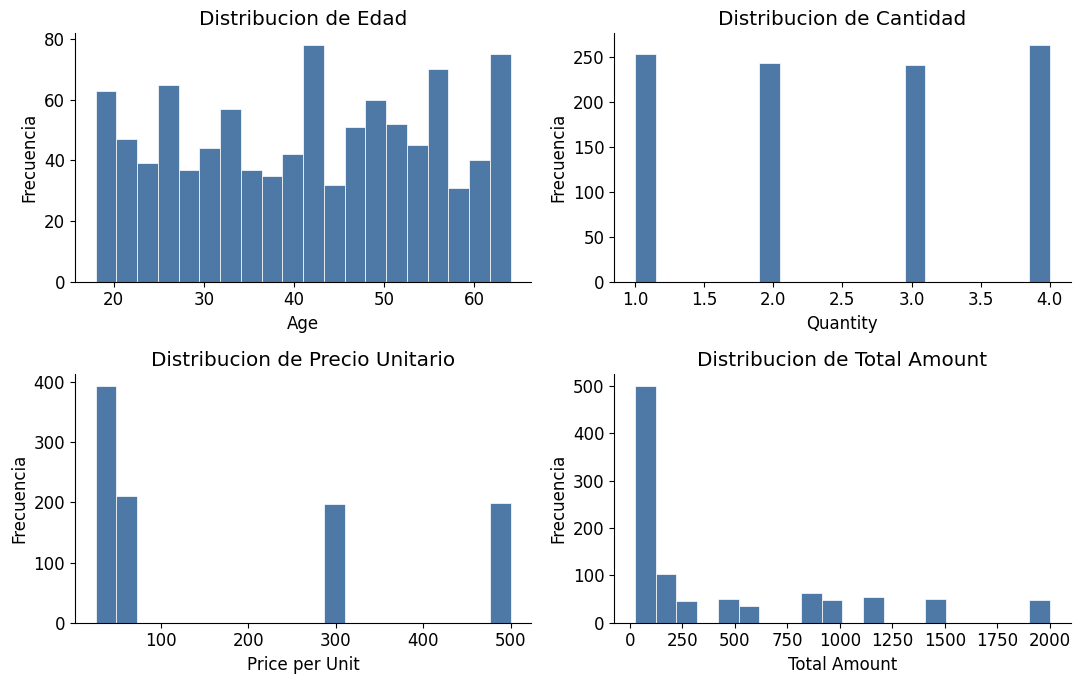

In [5]:
# Histograma de las variables numericas
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
nombres = ["Age", "Quantity", "Price per Unit", "Total Amount"]
titulos = ["Distribucion de Edad", "Distribucion de Cantidad",
           "Distribucion de Precio Unitario", "Distribucion de Total Amount"]
for ax, col, tit in zip(axes.flat, nombres, titulos):
    ax.hist(df[col], bins=20, color="#4E79A7", edgecolor="white", linewidth=0.5)
    ax.set_title(tit)
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
fig.savefig(IMGS_DIR / "histogramas_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

**Que vemos:**
- Edad: distribucion bastante uniforme entre 18 y 64. Sin picos raros.
- Cantidad: solo 4 valores (1 a 4). La mayoria compra 2 o 3 unidades.
- Precio Unitario: esto es lo mas raro. Solo 5 valores distintos: 25, 30,
  50, 300 y 500. Hay un saltote del percentil 50 ($50) al 75 ($300).
  En otras palabras, los productos son "baratos" (hasta $50) o "caros"
  (desde $300), sin punto medio. Eso justifica crear una variable binaria
  de nivel de precio.
- Total Amount: distribucion sesgada a la derecha (media $456, mediana
  $135). La mayoria de las transacciones son chicas pero hay algunas
  muy grandes que jalan el promedio para arriba.

---
## 4. Exploracion de variables categoricas

Veamos la distribucion de Genero y Categoria de Producto, y como se
relacionan con los ingresos.

In [6]:
print("--- Frecuencia de Genero ---")
print(df["Gender"].value_counts())
print()
print("--- Frecuencia de Categoria ---")
print(df["Product Category"].value_counts())
print()

# Grafico de barras: ingresos totales por categoria
cat_ing = df.groupby("Product Category")["Total Amount"].sum().sort_values()
print("--- Ingresos por categoria ---")
print(cat_ing.apply(lambda x: f"${x:,.0f}"))

--- Frecuencia de Genero ---
Gender
Female    510
Male      490
Name: count, dtype: int64

--- Frecuencia de Categoria ---
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

--- Ingresos por categoria ---
Product Category
Beauty         $143,515
Clothing       $155,580
Electronics    $156,905
Name: Total Amount, dtype: str


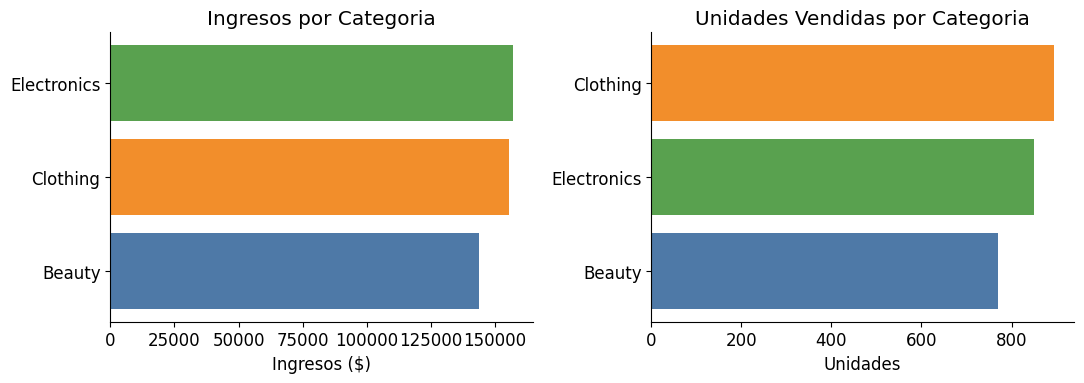

Ticket promedio por categoria:
Product Category
Beauty         $467.48
Clothing       $443.25
Electronics    $458.79
Name: Ticket, dtype: str


In [7]:
# Dos graficos lado a lado: ingresos y unidades por categoria
cat_stats = df.groupby("Product Category").agg(
    Ingresos=("Total Amount", "sum"),
    Unidades=("Quantity", "sum"),
    Ticket=("Total Amount", "mean")
).sort_values("Ingresos")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
colores = [COL_CAT[c] for c in cat_stats.index]

ax1.barh(cat_stats.index, cat_stats["Ingresos"], color=colores)
ax1.set_title("Ingresos por Categoria")
ax1.set_xlabel("Ingresos ($)")

unids = cat_stats.sort_values("Unidades")
colores2 = [COL_CAT[c] for c in unids.index]
ax2.barh(unids.index, unids["Unidades"], color=colores2)
ax2.set_title("Unidades Vendidas por Categoria")
ax2.set_xlabel("Unidades")

plt.tight_layout()
fig.savefig(IMGS_DIR / "ingresos_unidades_categoria.png", dpi=150, bbox_inches="tight")
plt.show()

print("Ticket promedio por categoria:")
print(cat_stats["Ticket"].apply(lambda x: f"${x:,.2f}"))

Las tres categorias estan sorprendentemente parejas en ingresos:
Electronics ($156K), Clothing ($155K), Beauty ($143K). Menos del 10%
de diferencia entre la que mas genera y la que menos. No es comun ver
tanta paridad entre categorias en datos reales.

En unidades vendidas el orden se invierte: Clothing vende mas, despues
Beauty, y Electronics vende menos. O sea, Electronics ingresa lo mismo
que Clothing pero vendiendo menos unidades, porque sus precios son mas
altos.

El ticket promedio es donde se ve la cosa: Beauty tiene el ticket mas
alto ($467), Electronics le sigue ($459), y Clothing cierra ($443).
Contraintuitivo: uno esperaria que Electronics tenga el ticket mas alto
porque vende productos caros, pero Beauty lo supera por poco. Las
diferencias son chicas en general, probablemente porque los precios base
($25, $30, $50, $300, $500) son los mismos para todas las categorias.

O sea, un labial de $50 y una camiseta de $50 son el mismo precio,
solo cambia la categoria. Por eso el ticket no varia tanto.

---
## 5. Tendencia temporal

Veamos como evolucionan las ventas a lo largo del ano.

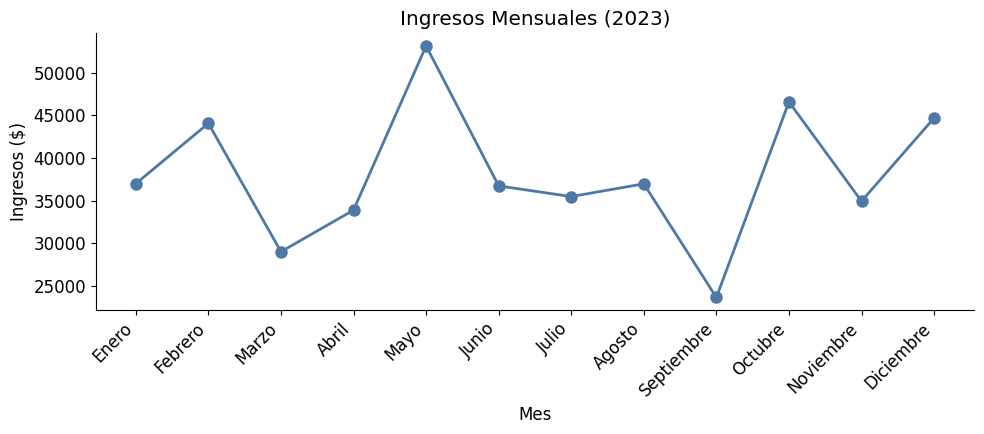

Mejor mes: Mayo ($53,150)
Peor mes: Septiembre ($23,620)
Promedio mensual: $38,000


In [8]:
df["MesNombre"] = df["Date"].dt.month.apply(
    lambda m: ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
              "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"][m-1]
)
serie_mensual = df.groupby("MesNombre")["Total Amount"].sum()
orden = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
         "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# Nos aseguramos de que los meses esten en orden cronologico
serie_mensual = serie_mensual.reindex(orden)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(serie_mensual.index, serie_mensual.values, marker="o",
        color="#4E79A7", linewidth=2, markersize=8)
ax.set_title("Ingresos Mensuales (2023)")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(IMGS_DIR / "ingresos_mensuales.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mejor mes:", serie_mensual.idxmax(), f"(${serie_mensual.max():,.0f})")
print("Peor mes:", serie_mensual.idxmin(), f"(${serie_mensual.min():,.0f})")
print("Promedio mensual:", f"${serie_mensual.mean():,.0f}")

La variacion mensual es fuerte. Mayo es el mejor mes con $53,150, mas del
doble que Septiembre ($23,620). El promedio mensual es $38,000.

Lo que llama la atencion: la caida de Agosto ($37K) a Septiembre ($24K)
y luego el repunte fuerte en Octubre ($47K). Sin datos de promociones,
feriados o inventario no podemos saber por que. Para el dashboard
conviene marcar el promedio como referencia.

Dato curioso: Diciembre ($45K) es el cuarto mes mas alto, pero no
el primero. En retail real diciembre suele dispararse por las fiestas.
Aca no pasa. Probablemente porque los datos son generados sin ese
factor estacional.

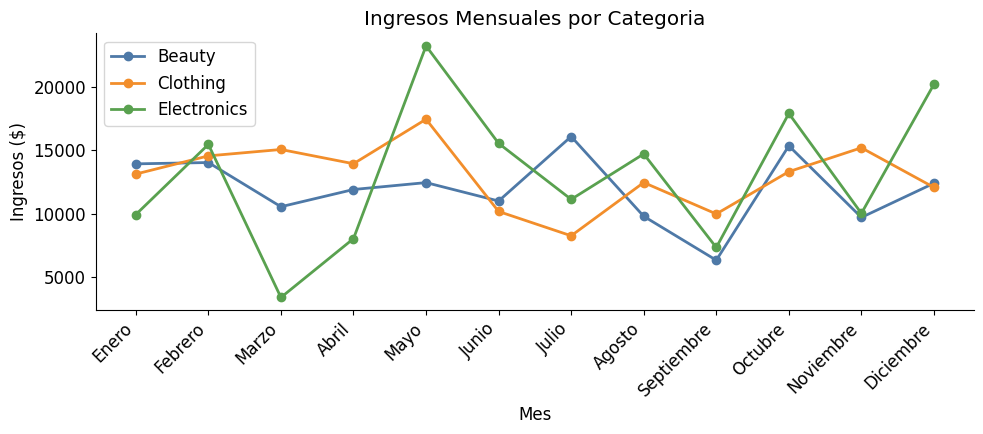

In [9]:
# Tendencia por categoria (lineas separadas)
cat_mes = df.groupby(["MesNombre", "Product Category"])["Total Amount"].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
for cat in ["Beauty", "Clothing", "Electronics"]:
    sub = cat_mes[cat_mes["Product Category"] == cat]
    # Reordenar por mes
    sub = sub.set_index("MesNombre").reindex(orden).reset_index()
    ax.plot(sub["MesNombre"], sub["Total Amount"], marker="o",
            label=cat, color=COL_CAT[cat], linewidth=2)
ax.set_title("Ingresos Mensuales por Categoria")
ax.set_xlabel("Mes")
ax.set_ylabel("Ingresos ($)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(IMGS_DIR / "ingresos_mensuales_categoria.png", dpi=150, bbox_inches="tight")
plt.show()

Cada categoria tiene su propio ritmo. Clothing es la mas estable a lo
largo del ano. Beauty y Electronics se mueven mas: picos en Mayo y
Octubre, valles en Septiembre.

Un detalle: las tres categorias se desploman en Septiembre al mismo
tiempo. No es que un producto este tirando el promedio para abajo,
es que Septiembre fue un mes malo para toda la tienda. Eso apunta a
un factor externo (estacionalidad, economia, o simple ruido en los
datos sinteticos).

---
## 6. Perfil demografico

Veamos como se comportan los ingresos por edad y genero.

In [10]:
# Creamos grupos de edad para el analisis
df["GrupoEdad"] = pd.cut(df["Age"], bins=[18, 25, 35, 45, 55, 65],
                          labels=["18-25", "26-35", "36-45", "46-55", "56-65"],
                          include_lowest=True, right=True)

piv = df.pivot_table(index="GrupoEdad", columns="Gender",
                     values="Total Amount", aggfunc="sum")

print("--- Ingresos por Grupo de Edad y Genero ---")
print(piv.map(lambda x: f"${x:,.0f}"))

--- Ingresos por Grupo de Edad y Genero ---
Gender      Female     Male
GrupoEdad                  
18-25      $39,470  $45,080
26-35      $55,115  $43,365
36-45      $46,735  $45,135
46-55      $53,310  $47,380
56-65      $38,210  $42,200


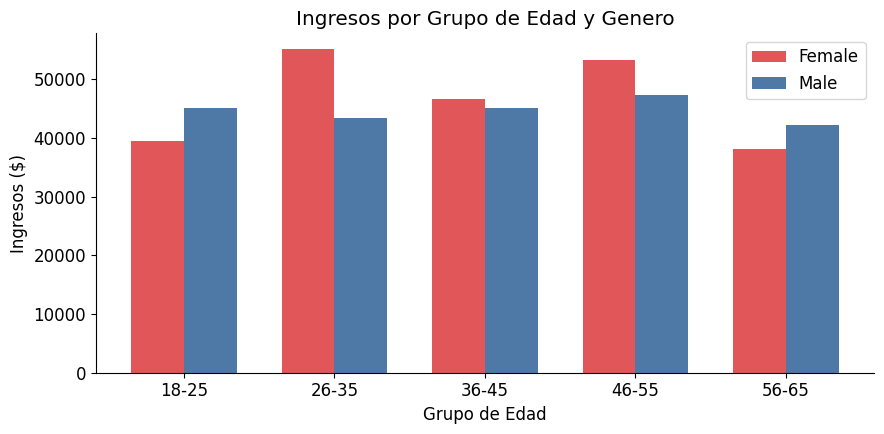

In [11]:
# Grafico de barras agrupadas
x = np.arange(len(piv.index))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x - w/2, piv["Female"], w, label="Female", color=COL_GEN["Female"])
ax.bar(x + w/2, piv["Male"], w, label="Male", color=COL_GEN["Male"])
ax.set_xticks(x)
ax.set_xticklabels(piv.index)
ax.set_title("Ingresos por Grupo de Edad y Genero")
ax.set_xlabel("Grupo de Edad")
ax.set_ylabel("Ingresos ($)")
ax.legend()
plt.tight_layout()
fig.savefig(IMGS_DIR / "ingresos_edad_genero.png", dpi=150, bbox_inches="tight")
plt.show()

El grupo 26-35 es el que mas gasta, seguido de cerca por 46-55. Los
extremos (18-25 y 56-65) gastan menos, lo cual es esperable por ingresos
disponibles.

Lo interesante es la dinamica por genero:
- 18-25: los hombres gastan un poco mas que las mujeres.
- 26-35: ahi se voltea, las mujeres gastan bastante mas ($55K vs $43K).
- 36-45: practicamente empatados.
- 46-55 y 56-65: los hombres vuelven a gastar un poco mas.

No sabria decir si esto es un patron real o ruido del dataset. Pero si
los datos fueran reales, el segmento mujeres de 26-35 seria el mas
valioso para campañas de marketing.

---
## 7. Relacion entre precio y cantidad

El scatter que sigue es el que mas nos costo que se entendiera.

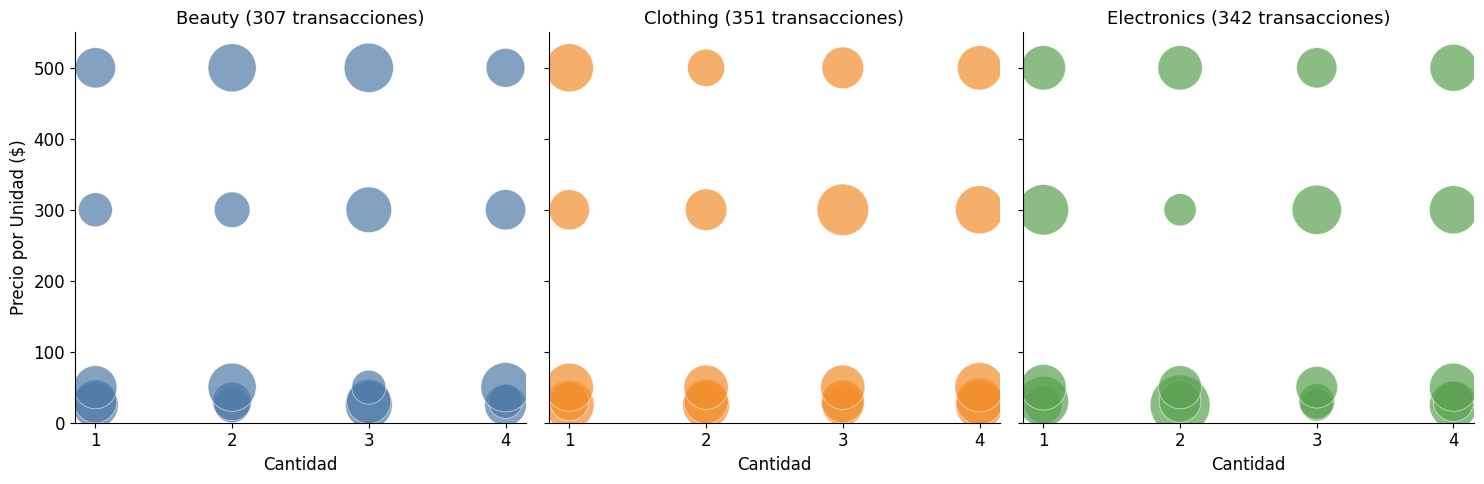

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for i, cat in enumerate(["Beauty", "Clothing", "Electronics"]):
    sub = df[df["Product Category"] == cat]
    counts = sub.groupby(["Quantity", "Price per Unit"]).size().reset_index(name="Count")
    axes[i].scatter(counts["Quantity"], counts["Price per Unit"],
                    s=counts["Count"]*60, alpha=0.7, color=COL_CAT[cat],
                    edgecolors="white", linewidth=0.5)
    axes[i].set_title(f"{cat} ({len(sub)} transacciones)", fontsize=13)
    axes[i].set_xlabel("Cantidad")
    axes[i].set_xticks([1, 2, 3, 4])
    axes[i].set_ylim(0, 550)
    if i == 0:
        axes[i].set_ylabel("Precio por Unidad ($)")
plt.tight_layout()
fig.savefig(IMGS_DIR / "precio_vs_cantidad.png", dpi=150, bbox_inches="tight")
plt.show()

Con los subplots separados por categoria se entiende mejor:

- **Beauty**: casi todo en precios de $25 a $50. Se compra en
  cantidades de 2 a 4 unidades. Producto economico y de consumo.
- **Electronics**: al reves. Predominan los precios de $300 a $500,
  1 o 2 unidades. Compra cara y poco frecuente.
- **Clothing**: es la unica categoria que mezcla ambos mundos. Tiene
  productos baratos (camisetas, calcetines) y caros (trajes, abrigos).

Esto confirma lo que veiamos en los histogramas: la variable relevante
no es tanto la categoria sino si el producto es caro o barato. Clothing
es la unica categoria que abarca todo el rango de precios.

Moraleja: en el dashboard, segmentar por nivel de precio puede ser
mas informativo que segmentar solo por categoria.

---
## 8. Analisis por dia de la semana

Para cerrar, veamos el patron semanal de ventas.

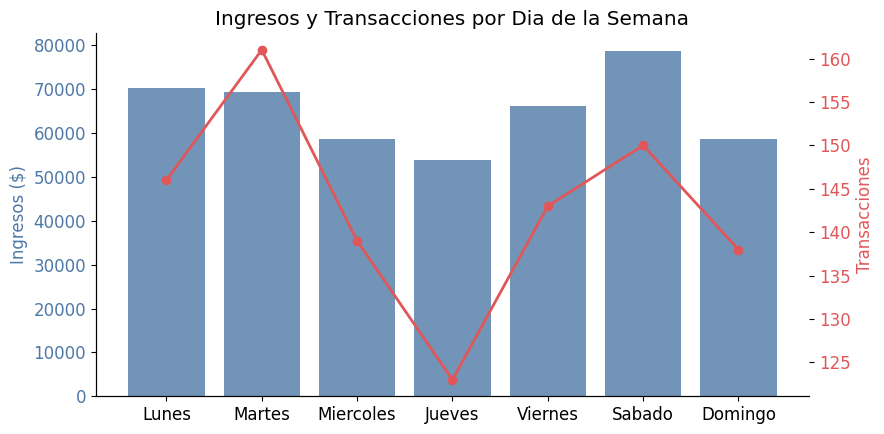

Ingresos:
DiaSemana
Lunes        $70,250
Martes       $69,440
Miercoles    $58,770
Jueves       $53,835
Viernes      $66,290
Sabado       $78,815
Domingo      $58,600
Name: Total Amount, dtype: str

Transacciones:
DiaSemana
Lunes        146
Martes       161
Miercoles    139
Jueves       123
Viernes      143
Sabado       150
Domingo      138
Name: Transaction ID, dtype: int64


In [13]:
dias = {0:"Lunes", 1:"Martes", 2:"Miercoles", 3:"Jueves",
        4:"Viernes", 5:"Sabado", 6:"Domingo"}
orden_dias = ["Lunes", "Martes", "Miercoles", "Jueves", "Viernes", "Sabado", "Domingo"]

df["DiaSemana"] = df["Date"].dt.dayofweek.map(dias)
ing_dia = df.groupby("DiaSemana")["Total Amount"].sum().reindex(orden_dias)
trans_dia = df.groupby("DiaSemana")["Transaction ID"].count().reindex(orden_dias)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
color_bar = "#4E79A7"
ax1.bar(ing_dia.index, ing_dia.values, color=color_bar, alpha=0.8, label="Ingresos")
ax1.set_ylabel("Ingresos ($)", color=color_bar)
ax1.tick_params(axis="y", labelcolor=color_bar)

ax2 = ax1.twinx()
color_line = "#E15759"
ax2.plot(trans_dia.index, trans_dia.values, marker="o",
         color=color_line, linewidth=2, label="Transacciones")
ax2.set_ylabel("Transacciones", color=color_line)
ax2.tick_params(axis="y", labelcolor=color_line)

ax1.set_title("Ingresos y Transacciones por Dia de la Semana")
fig.tight_layout()
fig.savefig(IMGS_DIR / "ingresos_dia_semana.png", dpi=150, bbox_inches="tight")
plt.show()

print("Ingresos:")
print(ing_dia.apply(lambda x: f"${x:,.0f}"))
print()
print("Transacciones:")
print(trans_dia)

Sabado lidera en ingresos ($79K), seguido de Lunes ($70K) y Martes
($69K). Jueves es el dia mas flojo ($54K).

Lo interesante: Martes tiene la mayor cantidad de transacciones (161)
pero no esta ni cerca de liderar en ingresos. Sabado, en cambio, tiene
menos transacciones (150) pero genera $10K mas. El ticket del Sabado
($525) es muy superior al del Martes ($431). La gente que compra el fin
de semana gasta mas por transaccion.

Lunes tambien tiene un ticket alto ($481) con pocas transacciones (146).
Tal vez los lunes compran menos personas, pero las que compran gastan
mas. O son datos sinteticos y no significa nada.

---
## 9. Derivacion de atributos y exportacion

In [14]:
MESES_SORT = {
    1:"01-Enero", 2:"02-Febrero", 3:"03-Marzo", 4:"04-Abril",
    5:"05-Mayo", 6:"06-Junio", 7:"07-Julio", 8:"08-Agosto",
    9:"09-Septiembre", 10:"10-Octubre", 11:"11-Noviembre", 12:"12-Diciembre"
}
DIAS_SORT = {
    0:"1-Lunes", 1:"2-Martes", 2:"3-Miercoles", 3:"4-Jueves",
    4:"5-Viernes", 5:"6-Sabado", 6:"7-Domingo"
}

# Atributos temporales
df["Anio"] = df["Date"].dt.year
df["Mes"] = df["Date"].dt.month
df["NombreMes"] = df["Mes"].map(MESES_SORT)
df["Trimestre"] = "T" + df["Date"].dt.quarter.astype(str)
df["DiaSemana"] = df["Date"].dt.dayofweek.map(DIAS_SORT)
df["TipoDia"] = df["Date"].dt.dayofweek.apply(
    lambda d: "Fin de semana" if d >= 5 else "Entre semana"
)

# Grupos de edad (vimos en el EDA que los rangos de 10 anos funcionan bien)
df["GrupoEdad"] = pd.cut(df["Age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"],
    include_lowest=True, right=True
).astype(str)

# Nivel de precio: los histogramas mostraron dos clusters naturales
df["NivelPrecio"] = df["Price per Unit"].apply(
    lambda p: "Bajo (<=$50)" if p <= 50 else "Alto (>=$300)"
)

print("Atributos finales (", len(df.columns), "):")
print(list(df.columns))
print()
print("Primeras filas del dataset limpio:")
df.head()

Atributos finales ( 18 ):
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'MesNombre', 'GrupoEdad', 'DiaSemana', 'Anio', 'Mes', 'NombreMes', 'Trimestre', 'TipoDia', 'NivelPrecio']

Primeras filas del dataset limpio:


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,MesNombre,GrupoEdad,DiaSemana,Anio,Mes,NombreMes,Trimestre,TipoDia,NivelPrecio
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,Noviembre,26-35,5-Viernes,2023,11,11-Noviembre,T4,Entre semana,Bajo (<=$50)
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,Febrero,26-35,1-Lunes,2023,2,02-Febrero,T1,Entre semana,Alto (>=$300)
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,Enero,46-55,5-Viernes,2023,1,01-Enero,T1,Entre semana,Bajo (<=$50)
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,Mayo,36-45,7-Domingo,2023,5,05-Mayo,T2,Fin de semana,Alto (>=$300)
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,Mayo,26-35,6-Sabado,2023,5,05-Mayo,T2,Fin de semana,Bajo (<=$50)


---
## 10. Resumen y resumen final

Ultimo chequeo antes de exportar: confirmamos los totales generales
y que no haya perdido filas en el proceso.

In [15]:
print("=" * 55)
print("RESUMEN DEL DATASET LIMPIO")
print("=" * 55)
print(f"{ 'Filas:':<25} {len(df):>10,}")
print(f"{ 'Columnas:':<25} {len(df.columns):>10}")
print(f"{ 'Ingresos totales:':<25} ${df['Total Amount'].sum():>8,.0f}")
print(f"{ 'Ticket promedio:':<25} ${df['Total Amount'].mean():>8,.2f}")
print(f"{ 'Unidades vendidas:':<25} {df['Quantity'].sum():>10,}")
print(f"{ 'Categorias:':<25} {df['Product Category'].nunique():>10}")
print(f"{ 'Rango de edad:':<25} {df['Age'].min()} - {df['Age'].max()}")
print(f"{ 'Rango de fechas:':<25} {df['Date'].min().date()} a {df['Date'].max().date()}")
print(f"{ 'Valores nulos:':<25} {df.isnull().sum().sum():>10}")
print(f"{ 'Filas duplicadas:':<25} {df.duplicated().sum():>10}")

# Exportamos
df.to_csv(CLEAN, index=False, encoding="utf-8-sig")
print()
print("CSV exportado a:", CLEAN)

RESUMEN DEL DATASET LIMPIO
Filas:                         1,000
Columnas:                         18
Ingresos totales:         $ 456,000
Ticket promedio:          $  456.00
Unidades vendidas:             2,514
Categorias:                        3
Rango de edad:            18 - 64
Rango de fechas:          2023-01-01 a 2024-01-01
Valores nulos:                     0
Filas duplicadas:                  0

CSV exportado a: C:\Users\Espin\Desktop\maestria\proyecto\dashboard_streamlit\retail_sales_clean.csv


---
## Lo que nos llevamos para el dashboard

Despues de darle vuelta a los datos, esto es lo que vamos a graficar:

1. **KPIs** - ingresos, transacciones, ticket promedio, unidades, edad,
   categorias.
2. **Ingresos por mes** - linea con promedio de referencia.
3. **Ingresos por mes y categoria** - para ver si todas se comportan
   igual o hay diferencias.
4. **Ingresos por categoria** - barras horizontales.
5. **Edad vs Genero** - barras agrupadas.
6. **Precio vs Cantidad** - burbujas por categoria (facetado).
7. **Ingresos por dia de la semana** - barras + linea de transacciones.

El dataset esta limpio, los atributos derivados creados, y sabemos que
la variable mas interesante no es la categoria sino el nivel de precio.
Eso lo vamos a incluir como filtro en el sidebar del dashboard.